In [9]:
!pip install langchain-groq


   ---------------------------------------- 0/2 [groq]
   ---------------------------------------- 2/2 [langchain-groq]



In [18]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import SystemMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_google_genai import ChatGoogleGenerativeAI

import os
from dotenv import load_dotenv

load_dotenv()
api_key = os.getenv('api_key')

llm = ChatGoogleGenerativeAI(
    model="models/gemini-2.5-flash",
    google_api_key=api_key,
    temperature=0.5,
    max_tokens=8000,
    timeout=None,
    max_retries=2,
)

In [19]:
prompt = ChatPromptTemplate.from_messages([
    SystemMessage(content="""
    너는 Cypher 쿼리를 생성하여 지식 그래프를 생성하는 데 도움을 주는 유용한 어시스턴트야.

    Task:
    컨텍스트로부터 엔티티 관계 그리고 속성 키를 식별해.
    지식 그래프를 생성하기 위해 식별한 엔티티 관계 속성 키로부터 Cypher 쿼리를 생성해.
    가능한 한 모든 엔티티와 관계를 추출해.
    항상 인물의 직업을 하나의 엔티티로 추출해.

    Note: Cypher 쿼리를 생성하기 전에 컨텍스트를 주의 깊게 두 번 읽어.
    Note: Cypher 쿼리 이외에는 아무것도 반환하지 마.
    Note: 너의 응답에 설명이나 사과문을 포함시키지 마.
                  
    Note: 할루시네이션을 발생시키면 안돼.
                  
    엔티티에는 사람, 장소, 제품, 직장, 회사, 도시, 국가, 동물, 그리고 사람의 직업과 같은 태그 등이 포함된다.
    """),
    ("human", "Context:{text}")
])

In [20]:
chain = prompt | llm | StrOutputParser()

In [ ]:
# Gemini가 생성한 텍스트
response = chain.invoke({
    "text":
    "김민준은 35세의 데이터 엔지니어이며, 현재 솔루션 기업 '넥스트데이터'에서 근무하고 있습니다. 넥스트데이터의 본사는 서울 테헤란로에 위치해 있으며, 클라우드 기반 데이터 분석 서비스를 제공합니다. 이성호는 넥스트데이터의 시니어 아키텍트이며, 김민준의 직속 상사입니다. 최지원은 28세의 UI/UX 디자이너로 프리랜서이며, 넥스트데이터와 협업하여 'AI 대시보드 리뉴얼' 프로젝트에 참여하고 있습니다. 김민준과 이성호는 Python과 SQL 기술을 보유하고 있으며, 최지원은 Figma와 React를 사용합니다. 이들은 지난달 'AI 대시보드 리뉴얼' 프로젝트의 1단계 개발을 완료했습니다."
})

In [ ]:
print(response)

```cypher
MERGE (p_kmj:Person {name: "김민준"})
SET p_kmj.age = 35;
MERGE (p_lsh:Person {name: "이성호"});
MERGE (p_cjw:Person {name: "최지원"})
SET p_cjw.age = 28, p_cjw.isFreelancer = true;

MERGE (jt_de:JobTitle {name: "데이터 엔지니어"});
MERGE (jt_sa:JobTitle {name: "시니어 아키텍트"});
MERGE (jt_uuxd:JobTitle {name: "UI/UX 디자이너"});

MERGE (c_nd:Company {name: "넥스트데이터"})
SET c_nd.type = "솔루션 기업";

MERGE (l_seoul:City {name: "서울"});
MERGE (l_teheranro:Location {name: "테헤란로"});

MERGE (proj_aidr:Project {name: "AI 대시보드 리뉴얼"})
SET proj_aidr.status = "1단계 개발 완료";

MERGE (s_python:Skill {name: "Python"});
MERGE (s_sql:Skill {name: "SQL"});
MERGE (s_figma:Skill {name: "Figma"});
MERGE (s_react:Skill {name: "React"});

MERGE (serv_cbda:Service {name: "클라우드 기반 데이터 분석 서비스"});

MERGE (p_kmj)-[:IS_A]->(jt_de);
MERGE (p_kmj)-[:WORKS_FOR]->(c_nd);
MERGE (p_kmj)-[:HAS_SKILL]->(s_python);
MERGE (p_kmj)-[:HAS_SKILL]->(s_sql);
MERGE (p_kmj)-[:PARTICIPATES_IN]->(proj_aidr);

MERGE (p_lsh)-[:IS_A]->(jt_sa);
MERGE (p_lsh)-

In [25]:
from langchain_core.documents import Document
from langchain_experimental.graph_transformers import LLMGraphTransformer

llm_transformer = LLMGraphTransformer(llm=llm)
documents = [Document(page_content=response)]
graph_documents = llm_transformer.convert_to_graph_documents(documents)

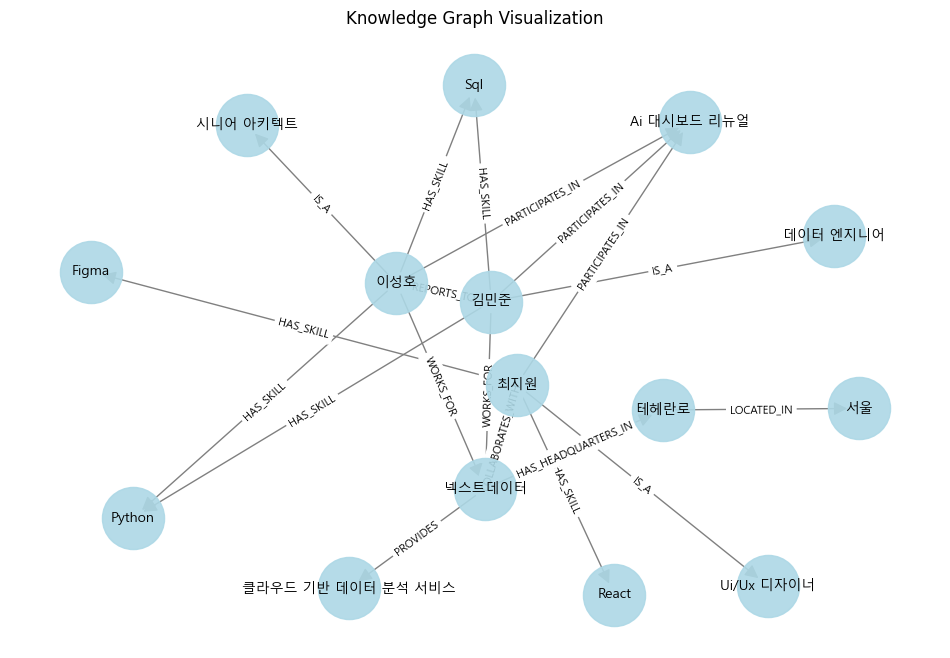

In [ ]:
# Gemini가 코딩해줌
import networkx as nx
import matplotlib.pyplot as plt

def visualize_graph(graph_documents):
    G = nx.DiGraph()

    # 1. 노드와 관계 추출 및 추가
    for doc in graph_documents:
        for node in doc.nodes:
            G.add_node(node.id, label=node.type)
        for rel in doc.relationships:
            G.add_edge(rel.source.id, rel.target.id, label=rel.type)

    # 2. 레이아웃 설정 (노드 배치)
    plt.figure(figsize=(12, 8))
    pos = nx.spring_layout(G, k=0.5)  # k값이 커질수록 노드 사이 거리가 멀어집니다.

    # 3. 노드 그리기
    nx.draw_networkx_nodes(G, pos, node_size=2000, node_color="#ADD8E6", alpha=0.9)
    
    # 4. 화살표(관계) 그리기
    nx.draw_networkx_edges(G, pos, width=1, edge_color="gray", arrowsize=20)

    # 5. 라벨(텍스트) 그리기
    # 노드 이름
    nx.draw_networkx_labels(G, pos, font_size=10, font_family="Malgun Gothic") # 한글 깨짐 방지
    
    # 관계 이름 (예: WORKS_AT, HAS_JOB 등)
    edge_labels = nx.get_edge_attributes(G, 'label')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8, font_family="Malgun Gothic")

    plt.title("Knowledge Graph Visualization")
    plt.axis('off')
    plt.show()

# 실행
visualize_graph(graph_documents)